In [1]:
import torch
import torch.nn as nn
import numpy as np
import platform

# Set random seeds
SEED = 35
np.random.seed(SEED)
torch.manual_seed(SEED)

# ============ ARCHITECTURE CONFIGURATION ============
# Switch between M2 Mac (ARM64) and AMD (x86_64) by changing DEVICE_TYPE
# Options: 'mps' (Apple M-series), 'cuda' (NVIDIA GPU), 'cpu'
# DEVICE_TYPE = 'mps'  # M2 Mac
DEVICE_TYPE = 'cuda'  # AMD with NVIDIA GPU
# DEVICE_TYPE = 'cpu'  # Fallback for any architecture

if DEVICE_TYPE == 'mps' and platform.system() == 'Darwin':
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
elif DEVICE_TYPE == 'cuda':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")
# =====================================================

Using device: cuda


# Federated Learning Baseline (Milestone 1)

Train a clean ResNet-18 on Tiny ImageNet under FedAvg with K=30 clients drawn from a Dirichlet(α=0.5) non-IID partition. m=6 clients are selected per round for R=25 rounds with E=8 local epochs each.

## Prerequisites

- Tiny ImageNet 200 dataset (see *Dataset Gathering* below for one-time setup)
- A CUDA-capable GPU is strongly recommended; training falls back to CPU but will be very slow

## Outputs

- `./models/fedavg_resnet18_baseline.pth` — final global model state
- `./histories/baseline.json` — per-round metrics (test_accuracy, avg_update_norm, avg_loss, per-client norms)

## Run order

1. Run **this notebook** first, end to end. It produces the `.pth` and `.json` consumed by `Poisoned.ipynb`.
2. Run `Poisoned.ipynb` second.

## Notes

- Hyperparameters in cell 8 are deliberately consistent with `Poisoned.ipynb` so metrics overlay cleanly. Do not change one without the other.
- All clients live on CPU between rounds and only move to GPU during their own training step, to keep memory bounded with 30 clients.

---

# Dataset Gathering

We assume you have an tiny-imagenet-set already extracted.
If this is your first time executing the ipynb file, follow these instructions:
1) Navigate to http://cs231n.stanford.edu/tiny-imagenet-200.zip and download the linked file
2) Extract the zip into the directory containing this ipynb. The structure should be something like `./tiny-imagenet-200/train`, `./tiny-imagenet-200/val`, `./tiny-imagenet-200/test`. If you have two tiny-imagenet-200 directories or similar, remove one.
3) Un-comment the block in the next code cell and run it once to reorganize `val/` into the per-class subfolder layout `ImageFolder` expects.
4) Remove the now-empty `./tiny-imagenet-200/val/images` directory.
5) Re-comment the block so it doesn't run again.


In [2]:
import os, shutil
#Preprocessing
val_dir = "tiny-imagenet-200/val"
img_dir = os.path.join(val_dir, "images")
anno_file = os.path.join(val_dir, "val_annotations.txt")



"""with open(anno_file) as f:
    for line in f:
        img, cls = line.split("\t")[:2]
        os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
        shutil.move(
            os.path.join(img_dir, img),
            os.path.join(val_dir, cls, img)
        )"""

'with open(anno_file) as f:\n    for line in f:\n        img, cls = line.split("\t")[:2]\n        os.makedirs(os.path.join(val_dir, cls), exist_ok=True)\n        shutil.move(\n            os.path.join(img_dir, img),\n            os.path.join(val_dir, cls, img)\n        )'

In [3]:
from torchvision import transforms, datasets
#Transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])
#For later display of the image:
unnormalize = transforms.Normalize(
    mean = [-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std = [1/s for s in [0.229, 0.224, 0.225]]
)

#Load dataset
train_dataset = datasets.ImageFolder(
    root='./tiny-imagenet-200/train',
    transform=transform_train
)
test_dataset = datasets.ImageFolder(
    root='./tiny-imagenet-200/val',
    transform=transform_val
)

In [4]:
import matplotlib.pyplot as plt

def find_and_display_matching_images(train_ds, test_ds, label_num):
    train_image = None
    train_label = None
    test_image = None

    # Find a sample from the training dataset
    for i in range(len(train_ds)):
        train_image, train_label = train_ds[i]
        if train_label != label_num:
          continue
        for j in range(len(test_ds)):
            test_img, test_lbl = test_ds[j]
            if train_label == test_lbl:
                test_image = test_img
                break
        if test_image is not None: # Found a match
            break

    if test_image is not None:
        # Unnormalize and convert to PIL Image for display
        pil_train_img = transforms.functional.to_pil_image(unnormalize(train_image))
        pil_test_img = transforms.functional.to_pil_image(unnormalize(test_image))

        # Display images
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(pil_train_img)
        axes[0].set_title(f"Train Image (Label: {train_label})")
        axes[0].axis('off')

        axes[1].imshow(pil_test_img)
        axes[1].set_title(f"Test Image (Label: {train_label})")
        axes[1].axis('off')

        plt.show()


find_and_display_matching_images(train_dataset, test_dataset, 2)

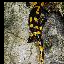

In [5]:
transforms.functional.to_pil_image(unnormalize(train_dataset[999][0]))

In [6]:
#Create dataloader (we have to partition the train dataloader later):
from torch.utils.data import DataLoader, Subset

# ============ PLATFORM-SPECIFIC DATALOADER CONFIG ============
# macOS and Windows need num_workers=0 to avoid multiprocessing issues
# Linux/AMD can use higher values for performance
PLATFORM_WORKERS = 0 if platform.system() in ['Darwin', 'Windows'] else 4
# ===========================================================

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=PLATFORM_WORKERS)

# Federated Learning Parameters

In [ ]:
# ============ FAST MODE vs PRODUCTION MODE ============
# Switch FAST_MODE to True for quick testing (minutes), False for full training (hours)
FAST_MODE = False
# ====================================================

if FAST_MODE:
    # ===== FAST TEST CONFIG (should run in ~3-5 minutes) =====
    NUM_CLIENTS = 4                  # Down from 30
    NUM_CLIENTS_PER_ROUND = 2        # Down from 6
    NUM_ROUNDS = 3                   # Down from 25
    LOCAL_EPOCHS = 1                 # Down from 8
    BATCH_SIZE = 64                  # Down from 128
    LEARNING_RATE = 0.01
    MOMENTUM = 0.9
    DIRICHLET_ALPHA = 0.5
    print("⚡ FAST MODE: Minimal viable test (expect ~3-5 min)")
else:
    # ===== PRODUCTION CONFIG (full training, ~1-2 hours) =====
    NUM_CLIENTS = 30
    NUM_CLIENTS_PER_ROUND = 6
    NUM_ROUNDS = 25
    LOCAL_EPOCHS = 8
    BATCH_SIZE = 128
    LEARNING_RATE = 0.01
    MOMENTUM = 0.9
    DIRICHLET_ALPHA = 0.5
    print("🚀 PRODUCTION MODE: Full training (expect ~1-2 hours)")

print(f"   Clients: {NUM_CLIENTS} | Per round: {NUM_CLIENTS_PER_ROUND} | Rounds: {NUM_ROUNDS} | Epochs: {LOCAL_EPOCHS}")

# IID Dataset generation

In [14]:
from collections import defaultdict
from torch.utils.data import DataLoader, Subset

#Divide the training dataset into clients for later use with the Dirichlet distribution

print(f"Clients: {NUM_CLIENTS}. ")
def divide_training_dataset(dataset, num_clients, alpha):
  """
  Returns a list of dataloaders dividing the training dataset into num_clients
  portions"""
  rng = np.random.default_rng(SEED + 1)
  num_classes = len(dataset.class_to_idx)
  samples_per_client = int(len(dataset) / num_clients)
  # Organize by class
  class_indices = defaultdict(list)
  for idx, label in enumerate(dataset.targets):
      class_indices[label].append(idx)

  print(f"Initial class sample counts: {[len(v) for k, v in class_indices.items()]}")

  client_dataloaders = []
  #Client data loop
  for client_id in range(num_clients):
    client_indicies = []
    #Data porpotions
    proportions = rng.dirichlet(np.ones(num_classes) * alpha)
    #This is an element wise multiplication: each element of proportions is multiplied by samples_per_client
    client_samples = samples_per_client  * proportions
    client_samples = np.floor(client_samples).astype(int)

    #Gather each class seperately
    for class_id in range(num_classes):
      available = class_indices[class_id]
      num_to_select = min(client_samples[class_id], len(available))
      #We need to make sure we actually have the samples available for use
      if num_to_select > 0:
        selected = rng.choice(available, num_to_select, replace=False)
        #Remove selected indicies from available ones
        class_indices[class_id] = list(set(available) - set(selected))
        client_indicies.extend(selected)
    #Finally we just pack each dataset subset into a dataloader
    client_dataloaders.append(DataLoader(Subset(dataset, client_indicies), batch_size=BATCH_SIZE, shuffle=True, num_workers=PLATFORM_WORKERS))
    print(f"Finished with client: {client_id}. Number of samples: {len(client_indicies)}\n", end="")

  #Anything remaining goes into a holdout dataset for future use.
  remaining_indicies = []
  for class_id in range(num_classes):
    remaining_indicies.extend(class_indices[class_id])
  holdout_dataset = Subset(dataset, remaining_indicies)



  return client_dataloaders, holdout_dataset

client_dataloaders, holdout_dataset = divide_training_dataset(train_dataset, NUM_CLIENTS, DIRICHLET_ALPHA)

Clients: 4. 
Initial class sample counts: [500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 50

#Model

In [15]:
import torchvision.models as models
import copy
def resnet18_tiny_imagenet(num_classes=200):
  model = models.resnet18(weights=None, num_classes=200)
  #TinyImagenet images are 64x64, so we have to change the first layer
  model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
  #Remove the max pooling layer to preserve more spatial information
  model.maxpool = nn.Identity()
  return model
def clone_resnet_model(state_dict, num_classes=200):
  new_model = resnet18_tiny_imagenet(num_classes)
  #Deep copy of state dict to avoid shenanigans
  new_model.load_state_dict(copy.deepcopy(state_dict))
  return new_model

# Federated Client

In [16]:
from tqdm.notebook import tqdm

#Federated Client
class Client:
  def __init__(self, client_id, dataloader):
    self.client_id = client_id
    self.dataloader = dataloader
    self.device = device
    self.model = resnet18_tiny_imagenet()
    self.criterion = nn.CrossEntropyLoss()
    self.is_adversary = False
  def get_state_dict(self):
    return self.model.state_dict()
  def load_state(self, state_dict):
    self.model.load_state_dict(copy.deepcopy(state_dict))
  def get_num_samples(self):
    return len(self.dataloader.dataset)
  def train_step(self, local_epochs=LOCAL_EPOCHS, lr=LEARNING_RATE, momentum=MOMENTUM, verbose=False):
    """
    Trains locally for n epochs
    Returns the loss, and the l2 between the intial and final state
    """
    intial_state = copy.deepcopy(self.model.state_dict())
    self.model.to(self.device)
    running_loss = 0.0
    optimizer = torch.optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)
    for epoch in tqdm(range(local_epochs), desc="Local Epoch:", leave=False):
      for images, labels in self.dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    if verbose:
      print(f"Client {self.client_id} done")
    self.model.to("cpu")
    l2_distance = 0.0
    for key in intial_state:
      if not torch.is_floating_point(intial_state[key]):
        continue
      l2_distance += torch.norm((intial_state[key] - self.model.state_dict()[key]).float()).item()
    return running_loss / len(self.dataloader), l2_distance
  def evaluate(self, test_dataloader, verbose=False):
    """
    Evaluates the model on the test dataset
    """
    criterion = nn.CrossEntropyLoss()
    self.model.to(self.device)
    self.model.eval()
    with torch.no_grad():
      running_loss = 0.0
      correct = 0
      for images, labels in test_dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        outputs = self.model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    if verbose:
      print(f"Client {self.client_id} done")
    self.model.to("cpu")
    return running_loss / len(test_dataloader), correct / len(test_dataloader.dataset)

In [17]:
class Server:
  def __init__(self, num_clients, client_dataloaders):
    self.num_clients = num_clients
    self.client_dataloaders = client_dataloaders
    self.device = device
    self.global_model = resnet18_tiny_imagenet().to(self.device)
    self.round_history = {
      'test_accuracy': [],
      'avg_update_norm': [],
      'avg_loss': [],
      'selected_clients': [],
      'client_norms': [],         # per-round list of per-client L2 norms
      'client_is_adversary': [],  # per-round list of bools, matched ordering
    }
  def get_state_dict(self):
    return self.global_model.state_dict()
  def load_state(self, state_dict):
    self.global_model.load_state_dict(copy.deepcopy(state_dict))
  def record_round(self, accuracy, avg_update_norm, avg_loss, selected_clients,
                   client_norms=None, client_is_adversary=None):
    self.round_history['test_accuracy'].append(float(accuracy))
    self.round_history['avg_update_norm'].append(float(avg_update_norm))
    self.round_history['avg_loss'].append(float(avg_loss))
    self.round_history['selected_clients'].append(selected_clients)
    self.round_history['client_norms'].append(
        [float(n) for n in (client_norms or [])])
    self.round_history['client_is_adversary'].append(
        [bool(b) for b in (client_is_adversary or [])])
  def get_accuracy_history(self):
    return self.round_history['test_accuracy']
  def get_history(self):
    return self.round_history
  def evaluate(self, test_dataloader):
    """Evaluates the global model on the test dataset. Returns (loss, accuracy)."""
    criterion = nn.CrossEntropyLoss()
    self.global_model.eval()
    with torch.no_grad():
      running_loss = 0.0
      correct = 0
      for images, labels in test_dataloader:
        images, labels = images.to(self.device), labels.to(self.device)
        outputs = self.global_model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
    return running_loss / len(test_dataloader), correct / len(test_dataloader.dataset)
  def aggregate(self, clients):
    """FedAvg algorithm. Each client's state is moved to CPU during aggregation
    to bound GPU memory; the new global state is moved back to GPU after."""
    client_dicts = [{k: v.to('cpu') for k, v in client.get_state_dict().items()} for client in clients]
    new_state_dict = {k: v.to('cpu') for k, v in copy.deepcopy(self.get_state_dict()).items()}
    for key in new_state_dict.keys():
        new_state_dict[key] = sum([s_dict[key] for s_dict in client_dicts]) / len(clients)
    self.load_state({k: v.to(self.device) for k, v in new_state_dict.items()})


In [18]:
from tqdm.notebook import tqdm

# Training loop
print(f"Initializing {NUM_CLIENTS} clients")
print(f"Clients per round: {NUM_CLIENTS_PER_ROUND}. Rounds: {NUM_ROUNDS}")

client_list = []
for id in range(NUM_CLIENTS):
  client_list.append(Client(id, client_dataloaders[id]))

server = Server(NUM_CLIENTS, client_dataloaders)
seen_clients = set()
outer_bar = tqdm(range(NUM_ROUNDS))
for round in outer_bar:
  outer_bar.set_description(f"Round {round + 1} Last 3 accuracies: {[f'{a:.3f}' for a in server.get_accuracy_history()[-3:]]}")
  global_state = server.get_state_dict()

  # Select active clients for this round
  active_clients = np.random.choice(client_list, NUM_CLIENTS_PER_ROUND, replace=False)
  round_loss = 0.0
  round_update_norm = 0.0
  client_norms_round = []
  client_is_adv_round = []

  # Train the active clients on their dataset
  bar = tqdm(enumerate(active_clients), leave=False, total=NUM_CLIENTS_PER_ROUND)
  for idx, chosen_client in bar:
    bar.set_description(f"Client {chosen_client.client_id} | size: {chosen_client.get_num_samples()} | seen: {chosen_client.client_id in seen_clients}")
    seen_clients.add(chosen_client.client_id)
    chosen_client.load_state(global_state)
    client_loss, client_norm = chosen_client.train_step()
    round_loss += client_loss
    round_update_norm += client_norm
    client_norms_round.append(client_norm)
    client_is_adv_round.append(chosen_client.is_adversary)
    # ============ DEVICE-AWARE CLEANUP ============
    # Only call CUDA functions if using CUDA
    if device.type == 'cuda':
      torch.cuda.synchronize()
      torch.cuda.empty_cache()
    # =============================================

  # Aggregate and evaluate
  server.aggregate(active_clients)
  loss, accuracy = server.evaluate(test_loader)
  server.record_round(
      accuracy=accuracy,
      avg_update_norm=round_update_norm / NUM_CLIENTS_PER_ROUND,
      avg_loss=round_loss / NUM_CLIENTS_PER_ROUND,
      selected_clients=[c.client_id for c in active_clients],
      client_norms=client_norms_round,
      client_is_adversary=client_is_adv_round,
  )
  if device.type == 'cuda':
    torch.cuda.empty_cache()

Initializing 4 clients
Clients per round: 2. Rounds: 3


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/1 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/1 [00:00<?, ?it/s]

...

Local Epoch::   0%|          | 0/1 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/1 [00:00<?, ?it/s]

Local Epoch::   0%|          | 0/1 [00:00<?, ?it/s]

Model Saving

In [19]:
if not (os.path.exists("./models")):
    os.mkdir("./models")
torch.save(server.global_model.state_dict(), "./models/fedavg_resnet18_baseline.pth")


In [20]:
import json
if not (os.path.exists("./histories")):
    os.mkdir("./histories")

baseline_data = {
    'config': {
        'run_type': 'baseline',
        'num_clients': NUM_CLIENTS,
        'num_clients_per_round': NUM_CLIENTS_PER_ROUND,
        'num_rounds': NUM_ROUNDS,
        'local_epochs': LOCAL_EPOCHS,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'momentum': MOMENTUM,
        'dirichlet_alpha': DIRICHLET_ALPHA,
        'seed': SEED,
    },
    'metrics': server.get_history(),
}

# Ensure all metric arrays are JSON-serializable
m = baseline_data['metrics']
m['test_accuracy']       = [float(x) for x in m['test_accuracy']]
m['avg_update_norm']     = [float(x) for x in m['avg_update_norm']]
m['avg_loss']            = [float(x) for x in m['avg_loss']]
m['client_norms']        = [[float(n) for n in row] for row in m['client_norms']]
m['client_is_adversary'] = [[bool(b) for b in row] for row in m['client_is_adversary']]

with open("./histories/baseline.json", "w") as f:
    json.dump(baseline_data, f, indent=2)

print(f"Final test accuracy: {m['test_accuracy'][-1]:.4f}")
print(f"Saved metrics to ./histories/baseline.json")


Final test accuracy: 0.0000
Saved metrics to ./histories/baseline.json


Pyplot Figures

In [21]:
def plot_training_curves(history):
    #Plot test accuracy, update norm, and loss curves
    fix, axes = plt.subplots(1, 3, figsize=(18, 5))
    #axes[0] is the test accuracy curve
    axes[0].plot(history['test_accuracy'])
    axes[0].set_title("Test Accuracy")
    axes[0].set_xlabel("Round")
    axes[0].set_ylim(0, 1)
    #Axes 1 is the update norm plot
    axes[1].plot(history['avg_update_norm'])
    axes[1].set_title("Average Update Norm")
    axes[1].set_xlabel("Round")
    #Axes 2 is the loss plot
    axes[2].plot(history['avg_loss'])
    axes[2].set_title("Average Client Loss")
    axes[2].set_xlabel("Round")
    plt.tight_layout()
    plt.show()

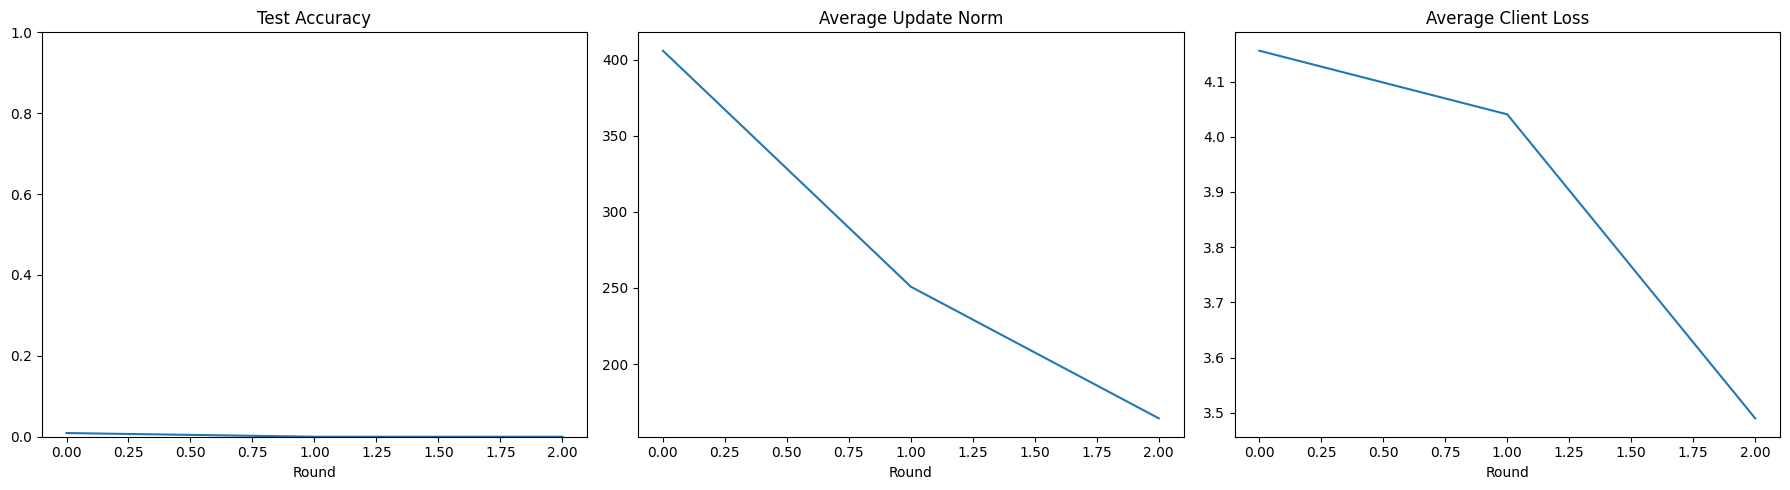

In [22]:
plot_training_curves(server.get_history())